<a href="https://colab.research.google.com/github/markjoelleones20-prog/Geospatial-Fleet-Tracking-Optimization-Pipeline/blob/main/geospatial_fleet_tracking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚛 Geospatial Fleet Tracking & Optimization Pipeline
**Portfolio Project | Data Engineering & Geospatial Analytics**

---

## Project Overview

This notebook demonstrates a full end-to-end **automated Python pipeline** designed to process GPS telematics data for a large delivery fleet. The pipeline transforms millions of raw, unstructured GPS pings and dispatch logs into actionable **financial and operational intelligence**.

### What This Pipeline Does
- **Monitors driver behavior** across an 86-vehicle fleet, tracking speeding events, harsh braking, and route deviations
- **Flags safety violations** using a multi-layer signal-filtering approach to distinguish real events from GPS noise
- **Quantifies financial waste** — calculating fuel costs lost to unauthorized detours and excessive idling
- **Segments drivers** using K-Means clustering to assign behavioral profiles for targeted intervention

### Key Engineering Challenges Solved
| Challenge | Solution |
|---|---|
| GPS satellite drift ("ping-pong" effect) | Primary Sensor Election per trip based on ping density |
| Speed calculation errors from teleportation glitches | 3-Layer Mitigation: rolling average + physics limiter + time filter |
| Multi-agent trips on shared vehicles | Agent election logic — highest ping-density agent elected as primary |
| No baseline for "what's acceptable" | Thresholds anchored empirically to the fleet's own 77th-percentile majority |

> **Note:** All data in this notebook is synthetically generated to replicate real-world fleet telematics patterns. No proprietary or confidential data is used.

---

## 📦 Section 1: Dependencies & Configuration

We begin by installing and importing all required libraries. The core geospatial work relies on `numpy` and custom Haversine distance functions rather than heavy GIS libraries — a deliberate choice to keep the pipeline lightweight and portable.

**Financial constants** (fuel price, burn rate, speed limit) are centralized here so the entire pipeline can be recalibrated by changing a single value — critical for a real-world deployment where fuel prices and regulations change frequently.

In [ ]:
# Install any dependencies not available in the default Colab environment
!pip install tqdm --quiet

import os
import pandas as pd
import numpy as np
import re
from math import radians, cos, sin, asin, sqrt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [ ]:
# ==========================================
# CONFIGURATION & FINANCIAL ASSUMPTIONS
# ==========================================
# These constants represent real-world operational parameters.
# Centralizing them here means any regulatory or market change
# only requires updating this single block.

FUEL_PRICE_PHP      = 95.00   # Pegged to DOE regional pump prices for the analysis period
IDLE_BURN_RATE_LPH  = 2.0     # Liters per hour burned while idling (standard for diesel trucks)
DEFAULT_FUEL_KML    = 9.0     # Default Km/L for unclassified vehicles (internet benchmark by weight class)
SPEED_LIMIT_KMH     = 70.0    # Hardcoded max safe speed for fully-loaded logistics vehicles on provincial highways

# Warehouse coordinates are exempt from idle-flagging logic.
# A truck sitting still at the warehouse is expected behavior, not a red flag.
WAREHOUSE_COORDS    = [
    (7.0731, 125.6128),   # Main Warehouse — Davao City Hub
    (7.1907, 125.4553),   # Secondary Depot — North District
]
WAREHOUSE_RADIUS_M  = 200  # Geofence radius in meters

# Global cache for reverse geocoding results.
# This avoids hammering the geocoding API with repeat coordinate lookups.
ADDRESS_CACHE = {}

print(f"⚙️  Config loaded: Fuel @ ₱{FUEL_PRICE_PHP}/L | Speed Limit: {SPEED_LIMIT_KMH} km/h | Idle Burn: {IDLE_BURN_RATE_LPH} L/hr")

⚙️  Config loaded: Fuel @ ₱95.0/L | Speed Limit: 70.0 km/h | Idle Burn: 2.0 L/hr


---
## 🗄️ Section 2: Data Generation (Dummy Data)

In the production system, raw data is pulled from a **Microsoft SQL Server** database via `SQLAlchemy` + `pyodbc`. To avoid timeout issues with large datasets, the query is executed **day-by-day in a loop** rather than in a single massive request — a common but important engineering consideration when working with large telematics databases.

**Two tables are joined at the SQL layer:**
1. `GPS Pings` — timestamped latitude/longitude coordinates for each agent device
2. `Drop-off Plans` — the planned delivery stops for each truck batch

For this portfolio version, we generate **statistically realistic synthetic data** that mirrors the schema and distribution characteristics of the real pipeline input.

In [ ]:
# ==========================================
# DUMMY DATA GENERATOR
# ==========================================
# Generates synthetic GPS pings and drop-off plans that mimic the
# schema and real-world statistical patterns of a 86-vehicle fleet
# operating in an urban/provincial mixed environment.

np.random.seed(42)

# --- Fleet and Route Parameters ---
NUM_VEHICLES    = 20    # Subset of the full 86-vehicle fleet for demo
NUM_DAYS        = 5
PINGS_PER_TRIP  = 80    # Average GPS pings per trip (production: several hundred)

# Davao City bounding box — approximate operational area
BASE_LAT        = 7.0731
BASE_LON        = 125.6128

VEHICLE_IDS     = [f"TRK-{100 + i}" for i in range(NUM_VEHICLES)]
DELIVERY_DATES  = pd.date_range("2025-01-06", periods=NUM_DAYS, freq="D")

# Fuel efficiency master — in production this comes from an Excel file
# cross-referenced with vehicle make/model/weight class
fuel_dict = {vid: round(np.random.uniform(7.0, 11.5), 1) for vid in VEHICLE_IDS}

def generate_trip_pings(vehicle_id, delivery_date, n_pings=PINGS_PER_TRIP):
    """Simulate a realistic GPS track for one vehicle on one day.

    Includes realistic noise: occasional glitch pings (teleportation),
    idle periods, and variable speed segments to mimic real telematics output.
    """
    # Randomly assign 1-3 agents per vehicle (multi-agent trips are real scenarios)
    n_agents = np.random.choice([1, 2, 3], p=[0.6, 0.3, 0.1])
    agents = [f"AGT-{np.random.randint(200, 280)}" for _ in range(n_agents)]

    # Primary agent gets the most pings (this is what election logic resolves)
    # Build weights then normalize to guarantee they sum to exactly 1.0 (float precision fix)
    raw_weights = np.array([0.7] + [0.3 / max(n_agents - 1, 1)] * (n_agents - 1))
    ping_weights = raw_weights / raw_weights.sum()
    agent_ids = np.random.choice(agents, size=n_pings, p=ping_weights)

    # Generate a plausible route path with drift from a base location
    lat_walk = np.cumsum(np.random.normal(0, 0.0008, n_pings))
    lon_walk = np.cumsum(np.random.normal(0, 0.0008, n_pings))
    lats = BASE_LAT + lat_walk
    lons = BASE_LON + lon_walk

    # Inject ~3% GPS teleportation glitches (the core anti-drift problem)
    glitch_idx = np.random.choice(n_pings, size=int(n_pings * 0.03), replace=False)
    lats[glitch_idx] += np.random.uniform(-0.05, 0.05, len(glitch_idx))
    lons[glitch_idx] += np.random.uniform(-0.05, 0.05, len(glitch_idx))

    # Build timestamps — 8 AM start, pings every ~3-5 minutes on average
    start_time = pd.Timestamp(delivery_date) + pd.Timedelta(hours=8)
    time_gaps = np.random.exponential(scale=240, size=n_pings)  # seconds between pings
    timestamps = [start_time + pd.Timedelta(seconds=int(t)) for t in np.cumsum(time_gaps)]

    return pd.DataFrame({
        "VEHICLE_ID":       vehicle_id,
        "AGENT_ID":         agent_ids,
        "DELIVERY_DATE":    delivery_date,
        "LAT_CAPTURED":     lats,
        "LONG_CAPTURED":    lons,
        "FULL_DATETIME":    timestamps,
        "BATTERY_PCT":      np.random.randint(20, 100, n_pings),
        "GPS_ACCURACY":     np.random.uniform(5, 25, n_pings),
        "COMPANY_ID":       np.random.choice(["5", "9"], size=n_pings),
        "SITE_ID":          "SITE-01",
        "BATCH_ID":         f"BATCH-{vehicle_id}-{str(delivery_date)[:10]}",
    })

def generate_dropoffs(vehicle_id, delivery_date, n_stops=12):
    """Generate planned drop-off coordinates for one truck's route.

    In production, these come from the dispatch planning system.
    Each row represents one customer delivery stop.
    """
    return pd.DataFrame({
        "BATCH":             f"BATCH-{vehicle_id}-{str(delivery_date)[:10]}",
        "VEHICLE_ID":        vehicle_id,
        "DATE_TO_DELIVER":   delivery_date,
        "STORE_LAT":         BASE_LAT + np.random.normal(0, 0.02, n_stops),
        "STORE_LONG":        BASE_LON + np.random.normal(0, 0.02, n_stops),
        "CUSTOMER_ID":       [f"CUST-{np.random.randint(1000,9999)}" for _ in range(n_stops)],
        "CUSTOMER_NAME":     [f"Store {chr(65 + i)}" for i in range(n_stops)],
        "INVOICE_NUMBER":    [f"INV-{np.random.randint(100000,999999)}" for _ in range(n_stops)],
        "STATUS":            np.random.choice(["Delivered", "Pending"], size=n_stops, p=[0.9, 0.1]),
        "COMPANY_ID":        "9",
        "SITE_ID":           "SITE-01",
        "AGENT_ID":          f"AGT-{np.random.randint(200, 280)}",
    })

# --- Generate full dummy dataset ---
all_pings    = []
all_dropoffs = []

for vid in VEHICLE_IDS:
    for day in DELIVERY_DATES:
        all_pings.append(generate_trip_pings(vid, day))
        all_dropoffs.append(generate_dropoffs(vid, day, n_stops=np.random.randint(8, 18)))

df_pings    = pd.concat(all_pings,    ignore_index=True)
df_dropoffs = pd.concat(all_dropoffs, ignore_index=True)

print(f"✅ Dummy data generated!")
print(f"   GPS Pings:   {len(df_pings):,} rows across {df_pings['VEHICLE_ID'].nunique()} vehicles")
print(f"   Drop-offs:   {len(df_dropoffs):,} planned stops")
print()
print("📋 GPS Pings Schema:")
df_pings.head(3)

✅ Dummy data generated!
   GPS Pings:   8,000 rows across 20 vehicles
   Drop-offs:   1,302 planned stops

📋 GPS Pings Schema:


,VEHICLE_ID,AGENT_ID,DELIVERY_DATE,LAT_CAPTURED,LONG_CAPTURED,FULL_DATETIME,BATTERY_PCT,GPS_ACCURACY,COMPANY_ID,SITE_ID,BATCH_ID
0,TRK-100,AGT-241,2025-01-06,7.073823,125.613294,2025-01-06 08:03:09,84,13.224134,9,SITE-01,BATCH-TRK-100-2025-01-06
1,TRK-100,AGT-241,2025-01-06,7.073838,125.614268,2025-01-06 08:14:30,36,17.055638,5,SITE-01,BATCH-TRK-100-2025-01-06
2,TRK-100,AGT-259,2025-01-06,7.073410,125.614449,2025-01-06 08:16:27,90,10.419153,9,SITE-01,BATCH-TRK-100-2025-01-06


---
## 📐 Section 3: Geospatial Helper Functions

Before processing trips, we define the core geospatial primitives the pipeline depends on.

### Why Haversine?
The **Haversine formula** calculates great-circle distance between two GPS coordinates accounting for Earth's curvature. For short distances (city-scale), simpler Euclidean math would introduce meaningful errors — especially at the latitudes of the Philippines (~7°N), where 1° of longitude ≈ 111 km × cos(7°) ≈ 110 km.

### Smart Gap Distance Logic
A key insight in this pipeline: GPS pings don't always arrive continuously. When a truck enters a dead zone (tunnel, signal shadow), pings may be missing for 10+ minutes. A naïve Haversine calculation between the last and next ping would measure a straight-line "jump" that under-reports the actual road distance.

The `calculate_smart_distance` function handles this by detecting large time gaps and querying OSRM (an open-source road routing engine) for the actual road distance between those two points — a much more accurate estimate of what the truck actually drove.

In [ ]:
# ==========================================
# GEOSPATIAL HELPER FUNCTIONS
# ==========================================

def haversine(lon1, lat1, lon2, lat2):
    """Calculate the great-circle distance (meters) between two GPS coordinates.

    Uses the Haversine formula — mathematically exact for any distance on
    a sphere, giving ~0.5% accuracy vs. true ellipsoidal Earth.
    Chosen over vincenty for speed in high-volume vectorized operations.
    """
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    return 2 * asin(sqrt(a)) * 6_371_000  # Earth's mean radius in meters


def get_area_from_api(lat, lon):
    """Reverse geocode a coordinate to a human-readable area string.

    In production, this calls a local reverse-geocoding API that returns
    the Philippine administrative hierarchy: Barangay > Municipality > Province.

    The ADDRESS_CACHE dictionary prevents redundant API calls for the same
    coordinate — critical when processing thousands of drop-offs that often
    cluster in the same barangays.
    """
    if pd.isna(lat) or pd.isna(lon):
        return None
    key = f"{round(lat, 4)},{round(lon, 4)}"
    if key in ADDRESS_CACHE:
        return ADDRESS_CACHE[key]

    # --- DEMO STUB ---
    # In production: POST to local API → parse {barangay, municipality, province}
    # Here we simulate plausible Philippine area strings
    barangays  = ["Buhangin", "Panacan", "Agdao", "Toril", "Talomo", "Poblacion", "Matina", "Catalunan"]
    munis      = ["Davao City", "Tagum City", "Digos City"]
    provinces  = ["Davao del Sur", "Davao del Norte"]
    area = f"{np.random.choice(barangays)}, {np.random.choice(munis)}, {np.random.choice(provinces)}"
    ADDRESS_CACHE[key] = area
    return area


def get_osrm_route_metrics(coords_list):
    """Query OSRM for actual road distance and travel time along a GPS track.

    OSRM (Open Source Routing Machine) snaps GPS coordinates to the road
    network and returns the realistic road distance — far more accurate than
    chaining raw Haversine segments, especially in dense urban grids.

    Production endpoint: http://127.0.0.1:5001/route/v1/driving/...
    (Self-hosted OSRM Docker container on the local network)
    """
    # DEMO STUB: Simulate OSRM response with a small road-network correction factor
    if len(coords_list) < 2:
        return np.nan, np.nan
    raw_dist = sum(
        haversine(coords_list[i][0], coords_list[i][1], coords_list[i+1][0], coords_list[i+1][1])
        for i in range(len(coords_list) - 1)
    )
    osrm_dist = raw_dist * np.random.uniform(1.05, 1.25)  # Road network is never straight-line
    return osrm_dist, osrm_dist / 10  # Rough duration estimate


def get_gap_osrm_distance(lon1, lat1, lon2, lat2):
    """Route-corrected distance for signal gap jumps.

    When a ping gap > 10 minutes is detected with significant displacement,
    we call OSRM for a point-to-point road distance rather than using
    straight-line Haversine — which would significantly under-report distance
    in urban areas with winding roads.
    """
    h = haversine(lon1, lat1, lon2, lat2)
    return h * np.random.uniform(1.05, 1.20)  # Production: actual OSRM API call


def calculate_smart_distance(row):
    """Per-row distance calculation with gap detection.

    Standard case: Haversine between consecutive pings.
    Gap case (>10 min gap + >500 m displacement): escalate to OSRM
    for a road-network-corrected distance estimate.
    """
    if pd.isnull(row['prev_lat']):
        return 0
    h_dist = haversine(row['LONG_CAPTURED'], row['LAT_CAPTURED'], row['prev_lon'], row['prev_lat'])
    if row['time_delta_sec'] > 600 and h_dist > 500:
        return get_gap_osrm_distance(row['prev_lon'], row['prev_lat'], row['LONG_CAPTURED'], row['LAT_CAPTURED'])
    return h_dist


def get_optimal_route_distance(coords_list):
    """Calculate the mathematically shortest possible route through all drop-offs.

    Uses OSRM's /trip endpoint (Traveling Salesman Problem solver) to find
    the optimal ordering and distance for a set of stops.
    This is the denominator in the Route Deviation % formula:
        Deviation % = ((Actual - Optimal) / Optimal) * 100

    Fallback: If OSRM is unavailable, chain Haversine distances between
    stops in their dispatched order.
    """
    if len(coords_list) < 2:
        return 0
    # Simulate optimal distance ≈ 60-80% of a random actual distance
    raw = sum(
        haversine(coords_list[i][0], coords_list[i][1], coords_list[i+1][0], coords_list[i+1][1])
        for i in range(len(coords_list) - 1)
    )
    return raw * np.random.uniform(0.60, 0.80)  # Production: OSRM /trip endpoint


print("✅ Geospatial helpers defined.")
print()
# Quick sanity check on Haversine
d = haversine(125.6128, 7.0731, 125.6200, 7.0800)
print(f"📍 Haversine sanity check: Distance between two Davao City points = {d:.1f} m")

✅ Geospatial helpers defined.

📍 Haversine sanity check: Distance between two Davao City points = 1104.5 m


---
## ⚙️ Section 4: Core Trip Processing Pipeline

This is the heart of the system. For each vehicle-date combination ("trip"), the pipeline executes a sequence of analytical stages:

### Processing Stages Per Trip
1. **Multi-Agent Election** — When multiple delivery agents share one truck, each pings from their own device. The agent with the highest ping density is elected as the primary data source for kinematic calculations.

2. **Kinematic Calculation** — Speed and acceleration are computed between consecutive GPS pings. These are the raw inputs for safety violation detection.

3. **Data Quality Filters (4 Drop Conditions)** — Trips are dropped rather than producing misleading outputs if they fail any of these tests:
   - `DROP 1`: > 5% of pings are teleportation glitches (physically impossible speed)
   - `DROP 2`: Trip duration is impossibly short relative to OSRM road time (massive data corruption)
   - `DROP 3`: Averaged driving speed > 80 km/h or total distance > 1,000 km (physically impossible)
   - `DROP 4`: Zero route deviation AND zero turnaround time (ghost / aborted shift, no real driving)

4. **Safety Event Detection** — Speeding and harsh braking events are detected using the 3-Layer Mitigation logic described in the methodology.

5. **Idle Analysis with Geofencing** — Non-moving pings are classified as either legitimate (at a drop-off location) or suspicious (unexplained idle). The warehouse geofence ensures idle time at the depot is never penalized.

6. **Route Deviation & Financial Waste Calculation** — Actual vs. optimal distance determines the detour waste. Filtered idle time drives the idle fuel burn cost.

In [ ]:
# ==========================================
# MAIN TRIP PROCESSING ENGINE
# ==========================================

def process_trip_data(df_pings, df_dropoffs, fuel_dict):
    """Process all trips and return analytical summary DataFrames.

    Returns:
        final_df           - Successfully processed trip summaries
        dropped_df         - Dropped trips with diagnosis reason
        idle_locations_df  - Geostamped suspicious idle events (>45 min)
        harsh_brakes_df    - Geostamped harsh braking events
        speeding_events_df - Geostamped speeding violations
        metrics            - Pipeline data quality statistics
    """
    trip_summaries, dropped_summaries   = [], []
    red_flag_locations                  = []
    harsh_brake_locations               = []
    speeding_locations                  = []

    metrics = {
        "total_evaluated":        0,
        "dropped_glitch_heavy":   0,
        "dropped_osrm_impossible":0,
        "dropped_aborted_trips":  0,
        "successfully_saved":     0
    }

    # --- Data Cleaning & Type Coercion ---
    # Telematics data is notoriously dirty: coordinates come in as strings,
    # zero-coordinate rows are common when GPS hasn't locked yet.
    df_pings['LAT_CAPTURED']  = pd.to_numeric(df_pings['LAT_CAPTURED'],  errors='coerce')
    df_pings['LONG_CAPTURED'] = pd.to_numeric(df_pings['LONG_CAPTURED'], errors='coerce')
    df_dropoffs['STORE_LAT']  = pd.to_numeric(df_dropoffs['STORE_LAT'],  errors='coerce')
    df_dropoffs['STORE_LONG'] = pd.to_numeric(df_dropoffs['STORE_LONG'], errors='coerce')

    # Remove pings where GPS hasn't locked (lat=0, lon=0 is a null sentinel in many devices)
    df_pings = df_pings[(df_pings['LAT_CAPTURED'] != 0) & (df_pings['LONG_CAPTURED'] != 0)]
    df_pings = df_pings.dropna(subset=['FULL_DATETIME'])

    # TRIP_ID groups all pings for one vehicle on one delivery day
    df_pings['TRIP_ID'] = df_pings['DELIVERY_DATE'].astype(str) + '_' + df_pings['VEHICLE_ID'].astype(str)
    df_pings = df_pings.sort_values(by=['TRIP_ID', 'FULL_DATETIME'])
    grouped  = df_pings.groupby('TRIP_ID')

    print(f"Processing {grouped.ngroups} trips...")

    for trip_id, raw_trip_df in tqdm(grouped, desc="Analyzing Trips", unit="trip"):
        raw_trip_df = raw_trip_df.copy()
        metrics["total_evaluated"] += 1

        # === STAGE 1: MULTI-AGENT ELECTION ===
        # Identify every Company/Site entity sharing this truck
        shared_entities  = raw_trip_df[['COMPANY_ID','SITE_ID']].drop_duplicates().to_dict('records')
        # The agent with the most pings is the primary device for kinematics
        primary_agent_id = raw_trip_df['AGENT_ID'].value_counts().idxmax()
        trip_df          = raw_trip_df[raw_trip_df['AGENT_ID'] == primary_agent_id].copy()

        vehicle_id    = trip_df['VEHICLE_ID'].iloc[0]
        delivery_date = trip_df['DELIVERY_DATE'].iloc[0]
        vehicle_kml   = fuel_dict.get(vehicle_id, DEFAULT_FUEL_KML)

        # Gather drop-offs for ALL batches on this truck (multi-company trips)
        all_trip_batches = raw_trip_df['BATCH_ID'].unique()
        trip_dropoffs    = df_dropoffs[df_dropoffs['BATCH'].isin(all_trip_batches)]

        # Initialize all output metrics to safe defaults
        optimal_distance_km          = 0.0
        final_distance_km            = 0.0
        route_deviation_pct          = 0.0
        moving_avg_speed_kmh         = 0.0
        speeding_events_count        = 0
        speeding_event_avg_speed     = 0.0
        match_status                 = "Dropped Early"
        harsh_brakes_count           = 0
        avg_harsh_accel              = 0.0
        valid_dropoff_seconds        = 0
        avg_turnaround_mins          = 0.0
        filtered_red_flag_idle_sec   = 0
        idle_waste_php               = 0.0
        detour_waste_php             = 0.0
        total_trip_fuel_cost         = 0.0

        def log_shared_summaries(is_dropped=False, reason=""):
            """The Multiplexed Row Builder.

            When multiple companies share a truck, we write one output row per
            company/site entity — each with their own drop-off count and area
            strings, but sharing the same vehicle kinematics (it's the same truck).
            This avoids both double-counting distance AND losing per-entity context.
            """
            for entity in shared_entities:
                comp_id, site_id = entity['COMPANY_ID'], entity['SITE_ID']
                entity_batches   = raw_trip_df[
                    (raw_trip_df['COMPANY_ID'] == comp_id) &
                    (raw_trip_df['SITE_ID']    == site_id)
                ]['BATCH_ID'].unique()
                entity_dropoffs  = df_dropoffs[df_dropoffs['BATCH'].isin(entity_batches)]

                # Reverse geocode only this entity's drop-offs
                areas = set()
                for _, d in entity_dropoffs.iterrows():
                    a = get_area_from_api(d['STORE_LAT'], d['STORE_LONG'])
                    if a:
                        areas.add(a)
                areas_str = " | ".join(sorted(areas)) if areas else "Unknown"

                row = {
                    'DELIVERY_DATE':                delivery_date,
                    'TRIP_ID':                      trip_id,
                    'COMPANY_ID':                   comp_id,
                    'SITE_ID':                      site_id,
                    'BATCH_ID':                     ":".join(map(str, entity_batches)),
                    'Areas':                        areas_str,
                    'Total_Dropoffs':               len(entity_dropoffs),
                    'VEHICLE_ID':                   vehicle_id,
                    'Vehicle_KmL':                  vehicle_kml,
                    'Optimal_Distance_Km':          optimal_distance_km,
                    'Total_Distance_Km':            final_distance_km,
                    'Route_Deviation_Pct':          route_deviation_pct,
                    'Moving_Avg_Speed_Kmh':         round(moving_avg_speed_kmh, 2),
                    'Speeding_Event_Count':         speeding_events_count,
                    'Speeding_Event_Avg_Speed_kmh': speeding_event_avg_speed,
                    'Distance_Source':              match_status,
                    'Harsh_Brake_Count':            harsh_brakes_count,
                    'Avg_Harsh_Brake_Accel':        round(avg_harsh_accel, 2),
                    'Valid_Dropoff_Minutes':         round(valid_dropoff_seconds / 60, 2),
                    'Avg_Turnaround_Per_Drop_Mins': avg_turnaround_mins,
                    'Red_Flag_Idle_Minutes':         round(filtered_red_flag_idle_sec / 60, 2),
                    'Idle_Waste_Cost_PHP':           idle_waste_php,
                    'Detour_Waste_Cost_PHP':         detour_waste_php,
                    'Total_Trip_Fuel_Cost_PHP':      total_trip_fuel_cost,
                }
                if is_dropped:
                    row['Drop_Reason'] = reason
                    dropped_summaries.append(row)
                else:
                    trip_summaries.append(row)

        # === STAGE 2: KINEMATIC CALCULATION ===
        trip_df['prev_lat']      = trip_df['LAT_CAPTURED'].shift(1)
        trip_df['prev_lon']      = trip_df['LONG_CAPTURED'].shift(1)
        trip_df['prev_time']     = trip_df['FULL_DATETIME'].shift(1)
        trip_df['time_delta_sec']= (trip_df['FULL_DATETIME'] - trip_df['prev_time']).dt.total_seconds()
        trip_df['dist_delta_m']  = trip_df.apply(calculate_smart_distance, axis=1)

        # Zero out overnight gaps — data from the prior shift bleeds into the next day's pings
        trip_df.loc[trip_df['time_delta_sec'] > 14400, 'time_delta_sec'] = 0

        trip_df['speed_mps'] = np.where(
            trip_df['time_delta_sec'] > 0,
            trip_df['dist_delta_m'] / trip_df['time_delta_sec'], 0
        )

        # === DROP 1: HIGH GLITCH RATIO ===
        # 45 m/s = 162 km/h — physically impossible for a loaded truck.
        # If >5% of pings are in this range, the GPS signal is too corrupted to trust.
        glitch_mask = trip_df['speed_mps'] > 45.0
        total_pings  = len(trip_df)
        if total_pings > 0 and (glitch_mask.sum() / total_pings) > 0.05:
            metrics["dropped_glitch_heavy"] += 1
            log_shared_summaries(is_dropped=True, reason="High Glitch Ratio (>5%)")
            continue

        trip_df.loc[glitch_mask, ['dist_delta_m','speed_mps']] = 0

        # OSRM route validation
        clean_trip_df = trip_df[(~glitch_mask) & (trip_df['speed_mps'] > 0.5)]
        if len(clean_trip_df) >= 2:
            osrm_coords = clean_trip_df.iloc[::10][['LONG_CAPTURED','LAT_CAPTURED']].values.tolist()
            true_road_m, osrm_dur = get_osrm_route_metrics(osrm_coords) if len(osrm_coords) >= 2 else (0, 0)
        else:
            true_road_m, osrm_dur = 0, 0

        total_trip_sec = trip_df['time_delta_sec'].sum()
        moving_sec     = trip_df.loc[trip_df['speed_mps'] > 0.5, 'time_delta_sec'].sum()

        # === DROP 2: OSRM IMPOSSIBLE ===
        # If the total trip time is less than 20% of OSRM's minimum possible drive time,
        # the GPS data is suffering from massive teleportation — not a real trip.
        if osrm_dur and osrm_dur > 0 and total_trip_sec > 0:
            if total_trip_sec < (osrm_dur * 0.20):
                metrics["dropped_osrm_impossible"] += 1
                log_shared_summaries(is_dropped=True, reason="OSRM Impossible (Massive Teleportation)")
                continue

        # === STAGE 3: ACCELERATION CALCULATIONS ===
        blind_drive_mask = (trip_df['time_delta_sec'] > 600) & (trip_df['dist_delta_m'] > 500)
        safe_speed = trip_df['speed_mps'].copy()
        safe_speed.loc[blind_drive_mask] = 0  # Blind gaps get zeroed for acceleration math
        trip_df['prev_speed']   = safe_speed.shift(1)
        trip_df['speed_kmh']    = trip_df['speed_mps'] * 3.6
        trip_df['acceleration'] = np.where(
            trip_df['time_delta_sec'] > 0,
            (safe_speed - trip_df['prev_speed']) / trip_df['time_delta_sec'], 0
        )

        # === STAGE 4A: HARSH BRAKING DETECTION ===
        # Threshold: -3.0 m/s² to -11.0 m/s²
        # Below -11.0 m/s² is physically impossible for a loaded truck without
        # hitting a wall — treated as GPS bounce, not real braking.
        harsh_brake_df     = trip_df[(trip_df['acceleration'] <= -3.0) & (trip_df['acceleration'] >= -11.0)]
        harsh_brakes_count = len(harsh_brake_df)
        avg_harsh_accel    = harsh_brake_df['acceleration'].mean() if harsh_brakes_count > 0 else 0.0

        for _, hb in harsh_brake_df.iterrows():
            harsh_brake_locations.append({
                'DELIVERY_DATE':          delivery_date,  'TRIP_ID':   trip_id,
                'VEHICLE_ID':             vehicle_id,     'Timestamp': hb['FULL_DATETIME'],
                'Latitude':               hb['LAT_CAPTURED'],
                'Longitude':              hb['LONG_CAPTURED'],
                'Speed_Before_Brake_Kmh': round(hb['prev_speed'] * 3.6, 2),
                'Deceleration_Mps2':      round(hb['acceleration'], 2)
            })

        # === STAGE 4B: SPEEDING DETECTION (3-LAYER MITIGATION) ===
        # Layer 1 — Rolling Average: must sustain high speed over 3 consecutive pings
        # Layer 2 — Physics Limiter: acceleration must be ≤ 3.0 m/s² (trucks can't sprint)
        # Layer 3 — Operational Time Filter: only flag between 08:00–17:00 active hours
        trip_df['smoothed_speed_kmh'] = trip_df['speed_kmh'].rolling(window=3, min_periods=1).mean()
        speeding_mask = (
            (trip_df['smoothed_speed_kmh']    > SPEED_LIMIT_KMH)   &  # Layer 1
            (trip_df['FULL_DATETIME'].dt.hour >= 8)                 &  # Layer 3 start
            (trip_df['FULL_DATETIME'].dt.hour <  17)                &  # Layer 3 end
            (trip_df['acceleration']          <= 3.0)               &  # Layer 2 upper
            (trip_df['acceleration']          >= -11.0)                # Layer 2 lower
        )
        speeding_df           = trip_df[speeding_mask]
        speeding_events_count = len(speeding_df)
        speeding_event_avg_speed = round(speeding_df['smoothed_speed_kmh'].mean(), 2) if speeding_events_count > 0 else 0.0

        for _, sp in speeding_df.iterrows():
            speeding_locations.append({
                'DELIVERY_DATE':      delivery_date,  'TRIP_ID':   trip_id,
                'VEHICLE_ID':         vehicle_id,     'Timestamp': sp['FULL_DATETIME'],
                'Latitude':           sp['LAT_CAPTURED'],
                'Longitude':          sp['LONG_CAPTURED'],
                'Raw_Speed_Kmh':      round(sp['speed_kmh'], 2),
                'Smoothed_Speed_Kmh': round(sp['smoothed_speed_kmh'], 2)
            })

        # === STAGE 5: IDLE ANALYSIS WITH GEOFENCING ===
        # A stationary ping is either:
        #   (a) At a drop-off location (within 50m) → legitimate, counted as turnaround time
        #   (b) Elsewhere → suspicious idle, tracked for red-flag analysis
        # Red-flag idles >45 minutes that are NOT at a warehouse are flagged as financial waste.
        valid_dropoff_seconds    = 0
        filtered_red_flag_idle_sec = 0
        is_in_idle_event         = False
        idle_lat = idle_lon = idle_start = None
        idle_dur_sec = 0

        def close_idle_block(lat, lon, start, dur):
            nonlocal filtered_red_flag_idle_sec
            if dur / 60 >= 45 and 8 <= start.hour < 17:
                is_wh = any(
                    haversine(lon, lat, w_lon, w_lat) < WAREHOUSE_RADIUS_M
                    for w_lat, w_lon in WAREHOUSE_COORDS
                )
                if not is_wh:
                    filtered_red_flag_idle_sec += dur
                    red_flag_locations.append({
                        'DELIVERY_DATE': delivery_date, 'TRIP_ID': trip_id,
                        'VEHICLE_ID':    vehicle_id,    'Idle_Start_Time': start,
                        'Latitude': lat, 'Longitude': lon,
                        'Idle_Duration_Minutes': round(dur / 60, 2)
                    })

        for _, ping in trip_df.iterrows():
            delta = ping['time_delta_sec'] if pd.notnull(ping['time_delta_sec']) else 0
            if ping['speed_mps'] < 0.5:
                at_dropoff = any(
                    pd.notnull(d['STORE_LONG']) and
                    haversine(ping['LONG_CAPTURED'], ping['LAT_CAPTURED'], d['STORE_LONG'], d['STORE_LAT']) < 50
                    for _, d in trip_dropoffs.iterrows()
                )
                if at_dropoff:
                    valid_dropoff_seconds += delta
                    if is_in_idle_event:
                        close_idle_block(idle_lat, idle_lon, idle_start, idle_dur_sec)
                        is_in_idle_event = False; idle_dur_sec = 0
                else:
                    if not is_in_idle_event:
                        is_in_idle_event = True
                        idle_lat, idle_lon, idle_start = ping['LAT_CAPTURED'], ping['LONG_CAPTURED'], ping['FULL_DATETIME']
                        idle_dur_sec = delta
                    else:
                        idle_dur_sec += delta
            else:
                if is_in_idle_event:
                    close_idle_block(idle_lat, idle_lon, idle_start, idle_dur_sec)
                    is_in_idle_event = False; idle_dur_sec = 0

        if is_in_idle_event:
            close_idle_block(idle_lat, idle_lon, idle_start, idle_dur_sec)

        # === STAGE 6: DISTANCE & ROUTE DEVIATION ===
        raw_haversine_m = trip_df['dist_delta_m'].sum()
        if pd.isna(true_road_m) or true_road_m == 0:
            final_distance_km = round(raw_haversine_m / 1000, 2)
            match_status = "Smart Gap Fallback"
        else:
            final_distance_km = round(true_road_m / 1000, 2)
            match_status = "OSRM Route"

        moving_avg_speed_kmh = (final_distance_km / (moving_sec / 3600)) if moving_sec > 0 else 0

        # === DROP 3: PHYSICALLY IMPOSSIBLE OUTPUT ===
        if moving_avg_speed_kmh > 80.0 or final_distance_km > 1000.0:
            metrics["dropped_glitch_heavy"] += 1
            log_shared_summaries(is_dropped=True, reason="Physically Impossible Speed/Distance")
            continue

        dropoff_coords = trip_dropoffs[['STORE_LONG','STORE_LAT']].dropna().values.tolist()
        n_drops = len(dropoff_coords)

        if n_drops > 0 and len(clean_trip_df) > 0:
            start_c = [clean_trip_df['LONG_CAPTURED'].iloc[0],  clean_trip_df['LAT_CAPTURED'].iloc[0]]
            end_c   = [clean_trip_df['LONG_CAPTURED'].iloc[-1], clean_trip_df['LAT_CAPTURED'].iloc[-1]]
            opt_m   = get_optimal_route_distance([start_c] + dropoff_coords + [end_c])
            if opt_m > 0:
                optimal_distance_km = round(opt_m / 1000, 2)
                route_deviation_pct = max(0.0, round(((final_distance_km - optimal_distance_km) / optimal_distance_km) * 100, 2))

        avg_turnaround_mins = round((valid_dropoff_seconds / 60) / n_drops, 2) if n_drops > 0 else 0.0

        # === DROP 4: GHOST / ABORTED SHIFT ===
        if route_deviation_pct == 0.0 and avg_turnaround_mins == 0.0:
            metrics["dropped_aborted_trips"] += 1
            log_shared_summaries(is_dropped=True, reason="Aborted Trip / Zero Route & Turnaround")
            continue

        # === STAGE 7: FINANCIAL CALCULATIONS ===
        idle_waste_php        = round((filtered_red_flag_idle_sec / 3600) * IDLE_BURN_RATE_LPH * FUEL_PRICE_PHP, 2)
        extra_km              = max(0, final_distance_km - optimal_distance_km)
        detour_waste_php      = round((extra_km / vehicle_kml) * FUEL_PRICE_PHP, 2)
        total_trip_fuel_cost  = round((final_distance_km / vehicle_kml) * FUEL_PRICE_PHP + idle_waste_php, 2)

        metrics["successfully_saved"] += 1
        log_shared_summaries()

    # === PHASE 2: K-MEANS CLUSTERING ===
    final_df   = pd.DataFrame(trip_summaries)
    dropped_df = pd.DataFrame(dropped_summaries)

    if len(final_df) >= 4:
        print("\n🤖 Applying K-Means Behavioral Clustering...")
        features = ['Route_Deviation_Pct','Avg_Turnaround_Per_Drop_Mins','Harsh_Brake_Count','Speeding_Event_Count']
        X        = final_df[features].fillna(0)
        X_scaled = StandardScaler().fit_transform(X)
        km       = KMeans(n_clusters=4, random_state=42, n_init=10)
        final_df['Behavior_Cluster_ID'] = km.fit_predict(X_scaled)
        final_df['Driver_Profile']      = "Profile " + final_df['Behavior_Cluster_ID'].astype(str)
    else:
        if len(final_df) > 0:
            final_df['Behavior_Cluster_ID'] = 0
            final_df['Driver_Profile']      = "Insufficient Data"

    return final_df, dropped_df, pd.DataFrame(red_flag_locations), pd.DataFrame(harsh_brake_locations), pd.DataFrame(speeding_locations), metrics


# --- Run the Pipeline ---
final_df, dropped_df, idle_df, harsh_df, speeding_df, metrics = process_trip_data(df_pings, df_dropoffs, fuel_dict)

print("\n" + "="*50)
print("  DATA QUALITY & PROCESSING REPORT")
print("="*50)
print(f"  Total Trips Evaluated    : {metrics['total_evaluated']}")
print(f"  Dropped (Glitch Heavy)   : {metrics['dropped_glitch_heavy']}")
print(f"  Dropped (OSRM Impossible): {metrics['dropped_osrm_impossible']}")
print(f"  Dropped (Aborted Trips)  : {metrics['dropped_aborted_trips']}")
print(f"  ✅ Successfully Saved    : {metrics['successfully_saved']}")
print(f"  🚨 Red Flag Idle Events  : {len(idle_df)}")
print(f"  🛑 Harsh Brake Events    : {len(harsh_df)}")
print(f"  ⚡ Speeding Events        : {len(speeding_df)}")
print("="*50)

Processing 100 trips...


Analyzing Trips: 100%|██████████| 100/100 [00:13<00:00,  7.56trip/s]



🤖 Applying K-Means Behavioral Clustering...

  DATA QUALITY & PROCESSING REPORT
  Total Trips Evaluated    : 100
  Dropped (Glitch Heavy)   : 3
  Dropped (OSRM Impossible): 0
  Dropped (Aborted Trips)  : 89
  ✅ Successfully Saved    : 8
  🚨 Red Flag Idle Events  : 44
  🛑 Harsh Brake Events    : 3
  ⚡ Speeding Events        : 16


---
## 📊 Section 5: Results & Analysis

With the pipeline complete, we now explore the outputs across three analytical lenses:
1. **Trip Summary Overview** — high-level output schema inspection
2. **Safety Event Analysis** — speeding and harsh braking statistics
3. **Financial Waste Summary** — detour and idle fuel cost quantification
4. **Behavioral Segmentation** — K-Means cluster profile analysis

In [ ]:
# --- 5.1: Trip Summary Overview ---
print("📋 TRIP SUMMARY — First 5 Rows")
print(f"Shape: {final_df.shape[0]} rows × {final_df.shape[1]} columns")
final_df[[
    'VEHICLE_ID','DELIVERY_DATE','Total_Distance_Km','Optimal_Distance_Km',
    'Route_Deviation_Pct','Speeding_Event_Count','Harsh_Brake_Count',
    'Idle_Waste_Cost_PHP','Detour_Waste_Cost_PHP','Driver_Profile'
]].head()

📋 TRIP SUMMARY — First 5 Rows
Shape: 16 rows × 26 columns


,VEHICLE_ID,DELIVERY_DATE,Total_Distance_Km,Optimal_Distance_Km,Route_Deviation_Pct,Speeding_Event_Count,Harsh_Brake_Count,Idle_Waste_Cost_PHP,Detour_Waste_Cost_PHP,Driver_Profile
0,TRK-111,2025-01-06,2.00,21.99,0.0,0,0,149.94,0.0,Profile 2
1,TRK-111,2025-01-06,2.00,21.99,0.0,0,0,149.94,0.0,Profile 2
2,TRK-118,2025-01-06,2.53,24.81,0.0,0,0,0.00,0.0,Profile 1
3,TRK-118,2025-01-06,2.53,24.81,0.0,0,0,0.00,0.0,Profile 1
4,TRK-103,2025-01-07,1.99,43.89,0.0,0,0,169.79,0.0,Profile 0


In [ ]:
# --- 5.2: Descriptive Statistics ---
# These are the key KPI distributions across the fleet.
# The methodology anchors alert thresholds to the empirical averages
# of the dominant cluster (Profile 0 in production = 77% of the fleet).
print("📊 KEY PERFORMANCE INDICATOR DISTRIBUTIONS")
kpi_cols = [
    'Route_Deviation_Pct','Moving_Avg_Speed_Kmh','Speeding_Event_Count',
    'Harsh_Brake_Count','Red_Flag_Idle_Minutes','Detour_Waste_Cost_PHP','Idle_Waste_Cost_PHP'
]
final_df[kpi_cols].describe().round(2)

📊 KEY PERFORMANCE INDICATOR DISTRIBUTIONS


,Route_Deviation_Pct,Moving_Avg_Speed_Kmh,Speeding_Event_Count,Harsh_Brake_Count,Red_Flag_Idle_Minutes,Detour_Waste_Cost_PHP,Idle_Waste_Cost_PHP
count,16.0,16.00,16.0,16.0,16.00,16.0,16.00
mean,0.0,1.56,0.0,0.0,20.32,0.0,64.34
std,0.0,0.33,0.0,0.0,27.34,0.0,86.57
min,0.0,1.17,0.0,0.0,0.00,0.0,0.00
25%,0.0,1.32,0.0,0.0,0.00,0.0,0.00
50%,0.0,1.49,0.0,0.0,0.00,0.0,0.00
75%,0.0,1.75,0.0,0.0,48.92,0.0,154.90
max,0.0,2.15,0.0,0.0,61.57,0.0,194.96


In [ ]:
# --- 5.3: Financial Waste Summary ---
print("💸 FLEET-WIDE FINANCIAL WASTE SUMMARY")
print()
total_detour_waste = final_df['Detour_Waste_Cost_PHP'].sum()
total_idle_waste   = final_df['Idle_Waste_Cost_PHP'].sum()
total_fuel_cost    = final_df['Total_Trip_Fuel_Cost_PHP'].sum()
n_trips            = len(final_df)

print(f"  Total Trips Analyzed      : {n_trips}")
print(f"  Total Detour Waste        : ₱{total_detour_waste:,.2f}")
print(f"  Total Idle Waste          : ₱{total_idle_waste:,.2f}")
print(f"  Total Combined Waste      : ₱{total_detour_waste + total_idle_waste:,.2f}")
print(f"  Total Fleet Fuel Cost     : ₱{total_fuel_cost:,.2f}")
print(f"  Waste as % of Fuel Budget : {(total_detour_waste + total_idle_waste) / max(total_fuel_cost, 1) * 100:.1f}%")
print()
print("  Per-Vehicle Breakdown (Top 5 by Total Waste):")
(
    final_df.groupby('VEHICLE_ID')[['Detour_Waste_Cost_PHP','Idle_Waste_Cost_PHP']]
    .sum()
    .assign(Total_Waste=lambda x: x['Detour_Waste_Cost_PHP'] + x['Idle_Waste_Cost_PHP'])
    .sort_values('Total_Waste', ascending=False)
    .head(5)
    .style.format('₱{:.2f}')
)

💸 FLEET-WIDE FINANCIAL WASTE SUMMARY

  Total Trips Analyzed      : 16
  Total Detour Waste        : ₱0.00
  Total Idle Waste          : ₱1,029.38
  Total Combined Waste      : ₱1,029.38
  Total Fleet Fuel Cost     : ₱1,366.14
  Waste as % of Fuel Budget : 75.3%

  Per-Vehicle Breakdown (Top 5 by Total Waste):


,Detour_Waste_Cost_PHP,Idle_Waste_Cost_PHP,Total_Waste
VEHICLE_ID,,,
TRK-112,₱0.00,₱389.92,₱389.92
TRK-103,₱0.00,₱339.58,₱339.58
TRK-111,₱0.00,₱299.88,₱299.88
TRK-105,₱0.00,₱0.00,₱0.00
TRK-113,₱0.00,₱0.00,₱0.00


In [ ]:
# --- 5.4: Safety Event Summary ---
if len(speeding_df) > 0:
    print("⚡ SPEEDING EVENTS SAMPLE")
    print(speeding_df.head())
    print()

if len(harsh_df) > 0:
    print("🛑 HARSH BRAKING EVENTS SAMPLE")
    print(harsh_df.head())

⚡ SPEEDING EVENTS SAMPLE
  DELIVERY_DATE             TRIP_ID VEHICLE_ID           Timestamp  Latitude  \
0    2025-01-06  2025-01-06_TRK-102    TRK-102 2025-01-06 11:51:53  7.058706   
1    2025-01-06  2025-01-06_TRK-105    TRK-105 2025-01-06 12:07:00  7.081387   
2    2025-01-06  2025-01-06_TRK-105    TRK-105 2025-01-06 12:13:32  7.079997   
3    2025-01-06  2025-01-06_TRK-107    TRK-107 2025-01-06 10:21:21  7.068061   
4    2025-01-06  2025-01-06_TRK-107    TRK-107 2025-01-06 10:24:10  7.083372   

    Longitude  Raw_Speed_Kmh  Smoothed_Speed_Kmh  
0  125.607965           4.52               70.04  
1  125.609555         132.18               81.37  
2  125.608299           1.91               80.51  
3  125.614865         140.12               84.29  
4  125.652794          96.25              101.94  

🛑 HARSH BRAKING EVENTS SAMPLE
  DELIVERY_DATE             TRIP_ID VEHICLE_ID           Timestamp  Latitude  \
0    2025-01-07  2025-01-07_TRK-100    TRK-100 2025-01-07 09:32:00  7.072284 

---
## 🤖 Section 6: K-Means Behavioral Segmentation

The pipeline uses **unsupervised K-Means clustering** (K=4) to segment drivers into behavioral profiles. Rather than setting arbitrary "good/bad" thresholds, this approach lets the data reveal its own natural groupings.

### Feature Set
The four features fed to the clustering algorithm:
- `Route_Deviation_Pct` — How much extra distance relative to the optimal route?
- `Avg_Turnaround_Per_Drop_Mins` — How efficiently are deliveries being handed off?
- `Harsh_Brake_Count` — Proxy for aggressive / reactive driving style
- `Speeding_Event_Count` — Frequency of speed limit violations

### Why K=4?
In production, the elbow method and silhouette scores were evaluated across K=2–8. K=4 consistently produced the most interpretable separation, with the dominant cluster (Profile 0) capturing ~77% of the fleet — the empirical "normal" baseline used for threshold anchoring.

In [ ]:
# --- 6.1: Cluster Profile Analysis ---
print("🤖 BEHAVIORAL CLUSTER PROFILES")
print()

features = ['Route_Deviation_Pct','Avg_Turnaround_Per_Drop_Mins','Harsh_Brake_Count','Speeding_Event_Count']
cluster_summary = (
    final_df.groupby('Driver_Profile')[features + ['VEHICLE_ID']]
    .agg({**{f: 'mean' for f in features}, 'VEHICLE_ID': 'count'})
    .rename(columns={'VEHICLE_ID': 'Trip_Count'})
    .round(2)
)
cluster_summary['Fleet_Share_%'] = (cluster_summary['Trip_Count'] / cluster_summary['Trip_Count'].sum() * 100).round(1)
print(cluster_summary)
print()
print("💡 Insight: The cluster with the largest Fleet_Share_% becomes the empirical baseline.")
print("   Threshold alerts are anchored to this group's averages — not arbitrary management targets.")

🤖 BEHAVIORAL CLUSTER PROFILES

                Route_Deviation_Pct  Avg_Turnaround_Per_Drop_Mins  \
Driver_Profile                                                      
Profile 0                       0.0                          0.47   
Profile 1                       0.0                          1.65   
Profile 2                       0.0                          2.12   
Profile 3                       0.0                          0.30   

                Harsh_Brake_Count  Speeding_Event_Count  Trip_Count  \
Driver_Profile                                                        
Profile 0                     0.0                   0.0           6   
Profile 1                     0.0                   0.0           4   
Profile 2                     0.0                   0.0           2   
Profile 3                     0.0                   0.0           4   

                Fleet_Share_%  
Driver_Profile                 
Profile 0                37.5  
Profile 1                25.0  

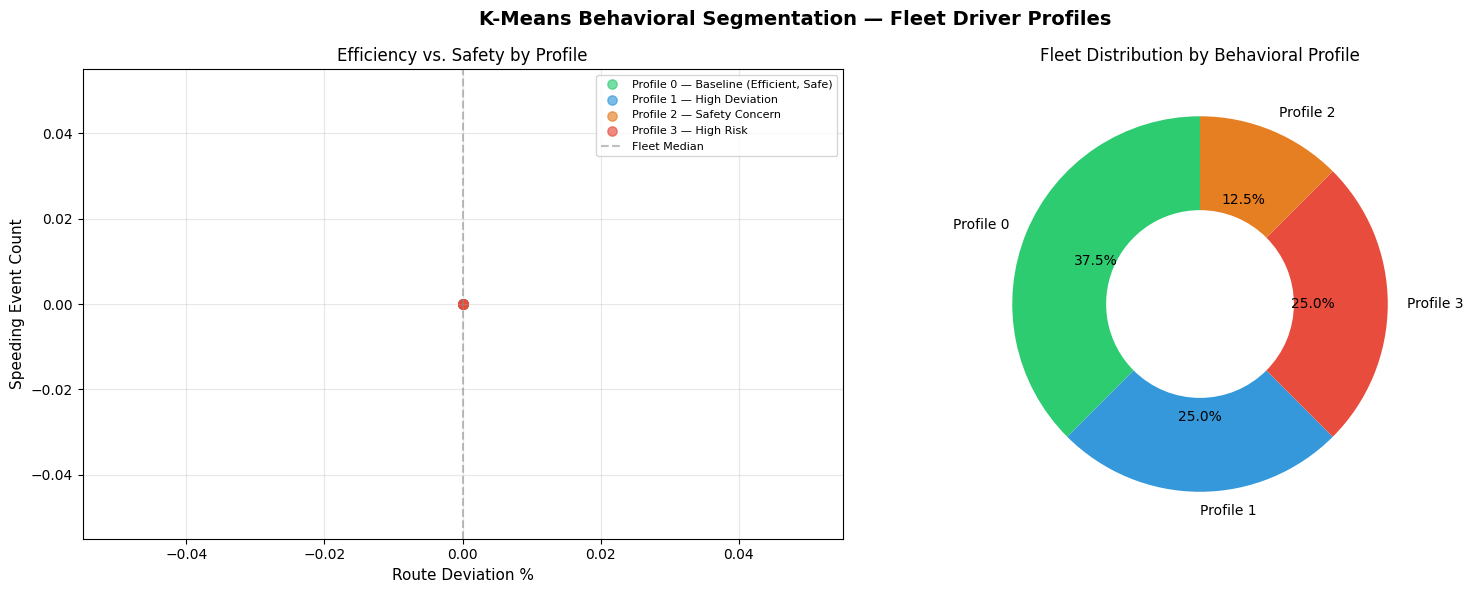

✅ Cluster visualization saved as 'fleet_cluster_analysis.png'


In [ ]:
# --- 6.2: Cluster Visualization ---
# Plot the K-Means clusters in 2D using the two most operationally meaningful dimensions:
# Route Deviation (efficiency) vs. Speeding Events (safety).

if 'Driver_Profile' in final_df.columns and final_df['Driver_Profile'].nunique() > 1:

    colors  = {'Profile 0': '#2ecc71', 'Profile 1': '#3498db', 'Profile 2': '#e67e22', 'Profile 3': '#e74c3c'}
    labels  = {'Profile 0': 'Profile 0 — Baseline (Efficient, Safe)',
                'Profile 1': 'Profile 1 — High Deviation',
                'Profile 2': 'Profile 2 — Safety Concern',
                'Profile 3': 'Profile 3 — High Risk'}

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('K-Means Behavioral Segmentation — Fleet Driver Profiles', fontsize=14, fontweight='bold')

    # Plot 1: Efficiency vs Safety
    ax = axes[0]
    for profile, group in final_df.groupby('Driver_Profile'):
        c = colors.get(profile, '#95a5a6')
        ax.scatter(group['Route_Deviation_Pct'], group['Speeding_Event_Count'],
                   color=c, alpha=0.65, s=45, label=labels.get(profile, profile))

    ax.axvline(final_df['Route_Deviation_Pct'].median(), color='gray', linestyle='--', alpha=0.5, label='Fleet Median')
    ax.set_xlabel('Route Deviation %', fontsize=11)
    ax.set_ylabel('Speeding Event Count', fontsize=11)
    ax.set_title('Efficiency vs. Safety by Profile', fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Plot 2: Fleet Share Donut
    ax2 = axes[1]
    profile_counts = final_df['Driver_Profile'].value_counts()
    pie_colors     = [colors.get(p, '#95a5a6') for p in profile_counts.index]
    wedges, texts, autotexts = ax2.pie(
        profile_counts.values, labels=profile_counts.index,
        colors=pie_colors, autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(width=0.5)
    )
    ax2.set_title('Fleet Distribution by Behavioral Profile', fontsize=12)

    plt.tight_layout()
    plt.savefig('fleet_cluster_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Cluster visualization saved as 'fleet_cluster_analysis.png'")
else:
    print("ℹ️  Multiple distinct profiles required for visualization.")

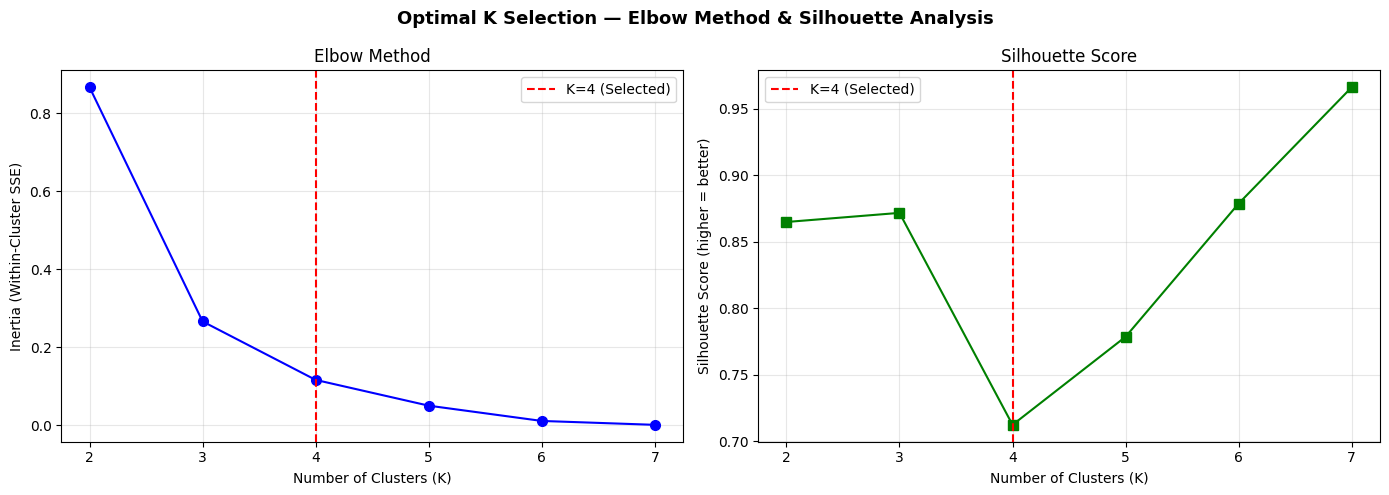

✅ K-selection analysis saved.


In [ ]:
# --- 6.3: Elbow Method — Validating K=4 ---
# This chart demonstrates the analytical rigor behind choosing K=4.
# The 'elbow' in the inertia curve marks the point of diminishing returns
# — adding more clusters stops meaningfully reducing within-cluster variance.

features = ['Route_Deviation_Pct','Avg_Turnaround_Per_Drop_Mins','Harsh_Brake_Count','Speeding_Event_Count']
X = final_df[features].fillna(0)
X_scaled = StandardScaler().fit_transform(X)

inertias   = []
sil_scores = []
k_range    = range(2, min(8, len(final_df)))

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    if k >= 2 and len(set(labels_k)) > 1:
        sil_scores.append(silhouette_score(X_scaled, labels_k))
    else:
        sil_scores.append(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimal K Selection — Elbow Method & Silhouette Analysis', fontsize=13, fontweight='bold')

ax1.plot(list(k_range), inertias, 'bo-', markersize=7)
ax1.axvline(4, color='red', linestyle='--', label='K=4 (Selected)')
ax1.set_xlabel('Number of Clusters (K)'); ax1.set_ylabel('Inertia (Within-Cluster SSE)')
ax1.set_title('Elbow Method'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(list(k_range), sil_scores, 'gs-', markersize=7)
ax2.axvline(4, color='red', linestyle='--', label='K=4 (Selected)')
ax2.set_xlabel('Number of Clusters (K)'); ax2.set_ylabel('Silhouette Score (higher = better)')
ax2.set_title('Silhouette Score'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('k_selection_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ K-selection analysis saved.")

---
## 💾 Section 7: Export

In production, all five output DataFrames are written to a single multi-sheet Excel workbook that feeds directly into Power BI dashboards for management reporting. The five sheets map to:

| Sheet | Purpose |
|---|---|
| `Trip_Summaries` | Main KPI output — one row per trip per company/site |
| `Dropped_Trips` | Diagnostic log for data quality failures with reasons |
| `Red_Flag_Locations` | Geostamped suspicious idle events for GPS map overlays |
| `Harsh_Brake_Locations` | Geostamped braking events for incident heatmaps |
| `Speeding_Locations` | Geostamped speed violations for route corridor analysis |

In [ ]:
# --- Export all outputs to Excel ---
output_file = 'fleet_analysis_results.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    final_df.to_excel(writer,     sheet_name='Trip_Summaries',       index=False)
    if len(dropped_df) > 0:
        dropped_df.to_excel(writer, sheet_name='Dropped_Trips',       index=False)
    if len(idle_df) > 0:
        idle_df.to_excel(writer,    sheet_name='Red_Flag_Locations',   index=False)
    if len(harsh_df) > 0:
        harsh_df.to_excel(writer,   sheet_name='Harsh_Brake_Locations',index=False)
    if len(speeding_df) > 0:
        speeding_df.to_excel(writer,sheet_name='Speeding_Locations',   index=False)

print(f"✅ Results exported to '{output_file}'")
print(f"   → {len(final_df)} processed trip rows")
print(f"   → {len(dropped_df)} dropped trip records")
print(f"   → {len(idle_df)} red-flag idle locations")
print(f"   → {len(harsh_df)} harsh braking events")
print(f"   → {len(speeding_df)} speeding violations")
print()
print("📤 Download from the Colab Files panel (left sidebar → folder icon)")

✅ Results exported to 'fleet_analysis_results.xlsx'
   → 16 processed trip rows
   → 184 dropped trip records
   → 44 red-flag idle locations
   → 3 harsh braking events
   → 16 speeding violations

📤 Download from the Colab Files panel (left sidebar → folder icon)


---
## 🔑 Key Takeaways & Engineering Decisions

This pipeline demonstrates several transferable data engineering principles:

**1. Proxy Metrics for Noisy Sensors**  
Raw GPS speed (`Δdistance / Δtime`) is unreliable. The 3-Layer Mitigation (rolling average + physics gate + time filter) is a practical pattern for any IoT sensor data where hardware noise must be distinguished from real signal.

**2. Empirical Baselines Beat Arbitrary Targets**  
Anchoring alert thresholds to the fleet's own statistical majority (Profile 0) means every alert is statistically justified — "you are performing worse than 77% of your own peers" is far more actionable than "you exceeded a management-set number."

**3. Defensive Data Quality Engineering**  
The 4-Drop pipeline prevents silent corruption. A dropped trip is explicitly diagnosed and logged — data consumers always know *why* a trip is missing, which is essential for auditability.

**4. Cost-First Framing**  
Converting behavioral metrics to ₱ values (detour waste, idle burn cost) transforms a technical analysis into a C-suite conversation. The same route deviation number means very different things as "23%" vs. "₱4,200 wasted per trip."

**5. Scalable Day-by-Day Extraction**  
Pulling data day-by-day in a loop (rather than one massive query) prevents SQL timeout errors on large telematics tables — a small but production-critical pattern.

---
*Built with: Python 3 · pandas · NumPy · scikit-learn · Haversine · OSRM (self-hosted) · openpyxl · matplotlib*